# Unemployment Analysis with Python

## Objective

To analyze unemployment trends in India using Python and identify regional and temporal patterns, including the impact of the COVID-19 pandemic on unemployment rates.

## Techniques Used

* Data Loading and Inspection
* Data Cleaning and Preprocessing
* Date Conversion
* Exploratory Data Analysis (EDA)
* Region-wise Unemployment Analysis
* Month-wise Trend Analysis
* State-wise Time-Series Analysis
* Top 10 Regions Analysis
* Correlation Analysis
* Pre-COVID vs Post-COVID Comparison
* Data Visualization using Matplotlib and Seaborn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/mamirobotics/CodeAlpha_Unemployment-Analysis-with-Python/main/Unemployment%20in%20India.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [4]:
df.dtypes

Region                                          str
 Date                                           str
 Frequency                                      str
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                            str
dtype: object

In [5]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [6]:
df.columns = df.columns.str.strip()

In [7]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [8]:
df['Date'].dtype

dtype('<M8[us]')

In [9]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [10]:
region_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

region_unemployment

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

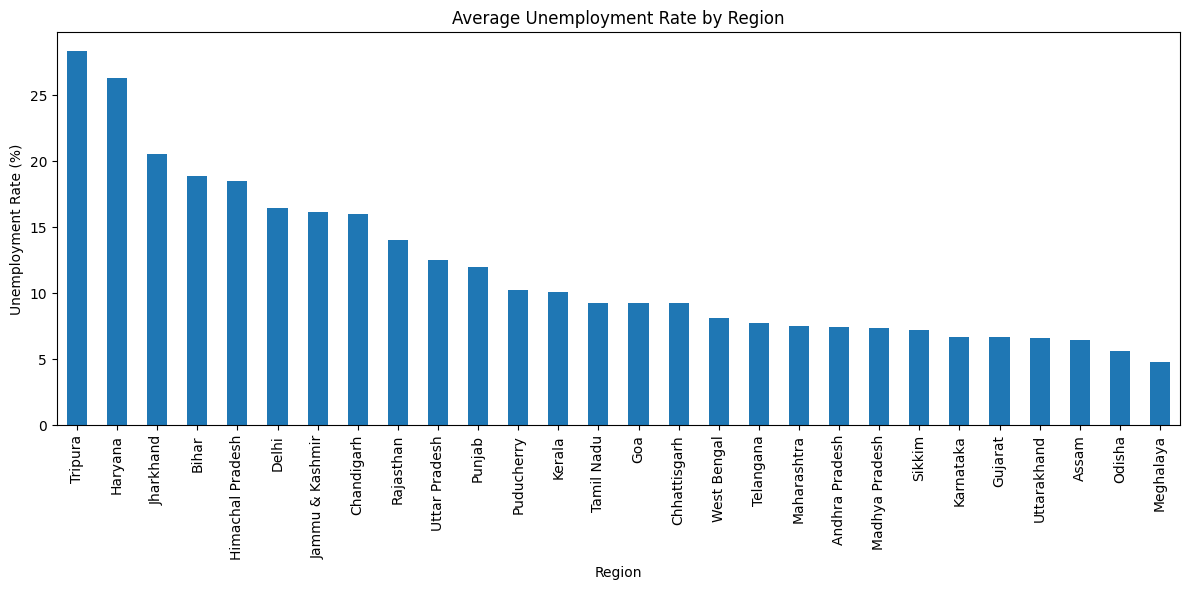

In [11]:
plt.figure(figsize=(12, 6))

region_unemployment.plot(kind='bar')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [12]:
monthly_unemployment = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

monthly_unemployment

Date
2019-05-31     8.874259
2019-06-30     9.303333
2019-07-31     9.033889
2019-08-31     9.637925
2019-09-30     9.051731
2019-10-31     9.900909
2019-11-30     9.868364
2019-12-31     9.497358
2020-01-31     9.950755
2020-02-29     9.964717
2020-03-31    10.700577
2020-04-30    23.641569
2020-05-31    24.875294
2020-06-30    11.903600
Name: Estimated Unemployment Rate (%), dtype: float64

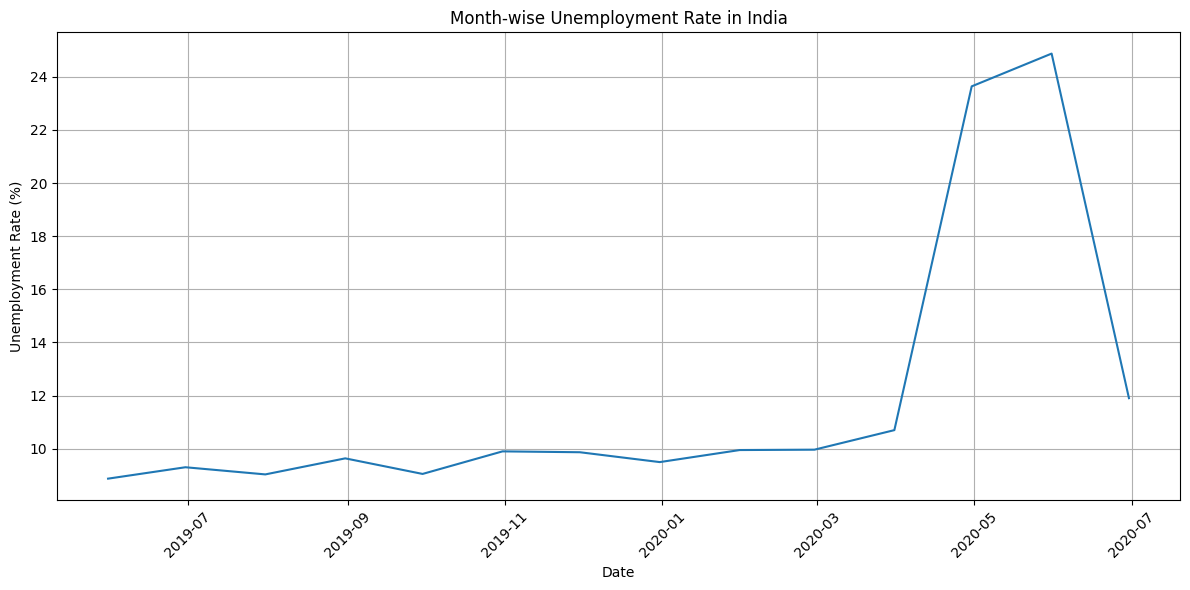

In [13]:
plt.figure(figsize=(12, 6))

plt.plot(monthly_unemployment.index, monthly_unemployment.values)

plt.title('Month-wise Unemployment Rate in India')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
df['Region'].unique()

<StringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal',
                nan,       'Chandigarh']
Length: 29, dtype: str

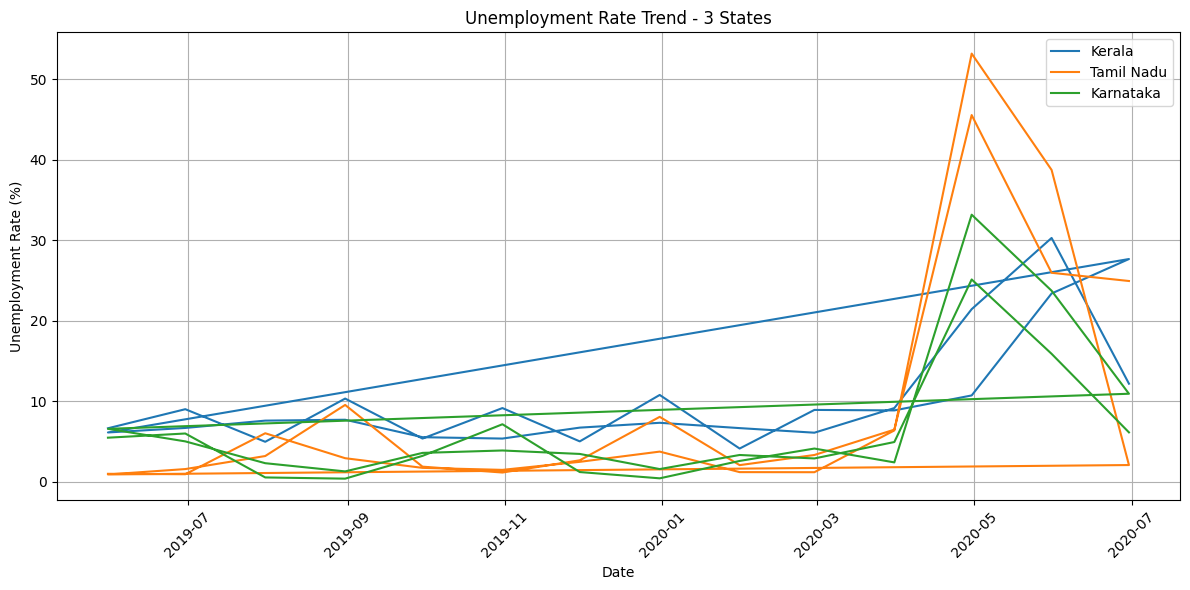

In [15]:
states = ['Kerala', 'Tamil Nadu', 'Karnataka']

plt.figure(figsize=(12, 6))

for state in states:
    state_data = df[df['Region'] == state]
    plt.plot(
        state_data['Date'],
        state_data['Estimated Unemployment Rate (%)'],
        label=state
    )

plt.title('Unemployment Rate Trend - 3 States')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
top_10_states = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_10_states

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

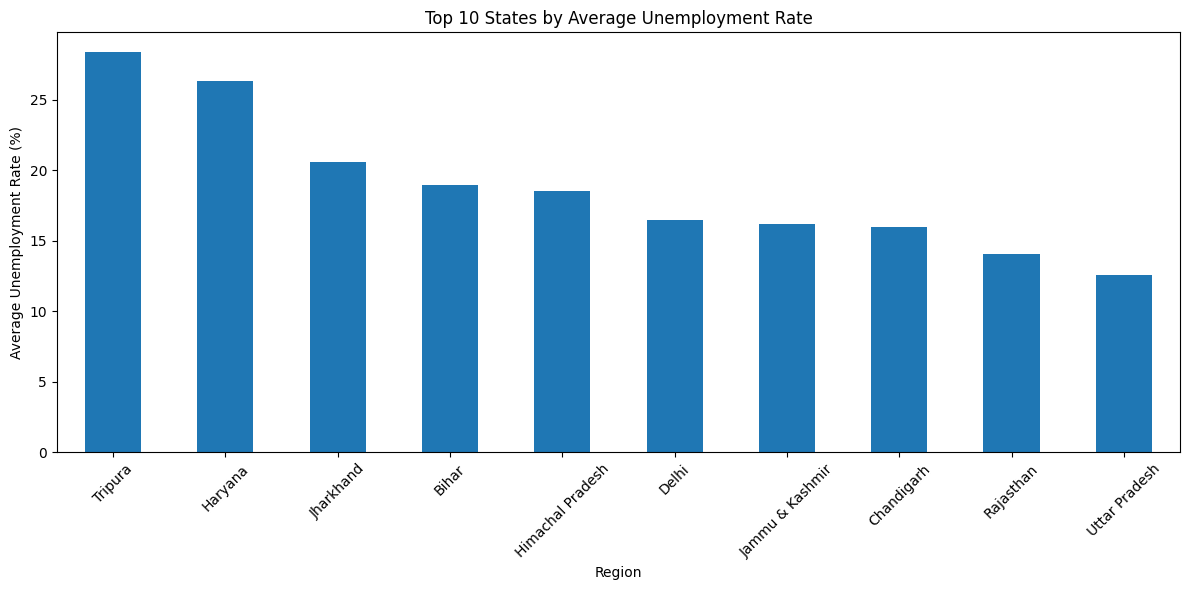

In [17]:
plt.figure(figsize=(12, 6))

top_10_states.plot(kind='bar')

plt.title('Top 10 States by Average Unemployment Rate')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

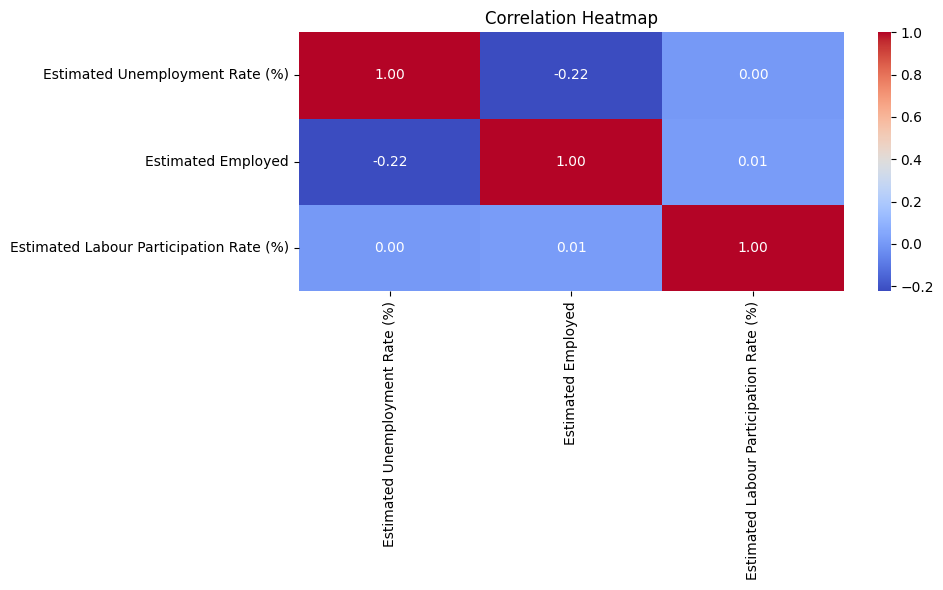

In [18]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [19]:
df['Period'] = df['Date'].apply(
    lambda x: 'Pre-COVID' if x < pd.Timestamp('2020-03-01') else 'Post-COVID'
)

In [20]:
covid_comparison = df.groupby('Period')['Estimated Unemployment Rate (%)'].mean()

covid_comparison

Period
Post-COVID    17.774363
Pre-COVID      9.509534
Name: Estimated Unemployment Rate (%), dtype: float64

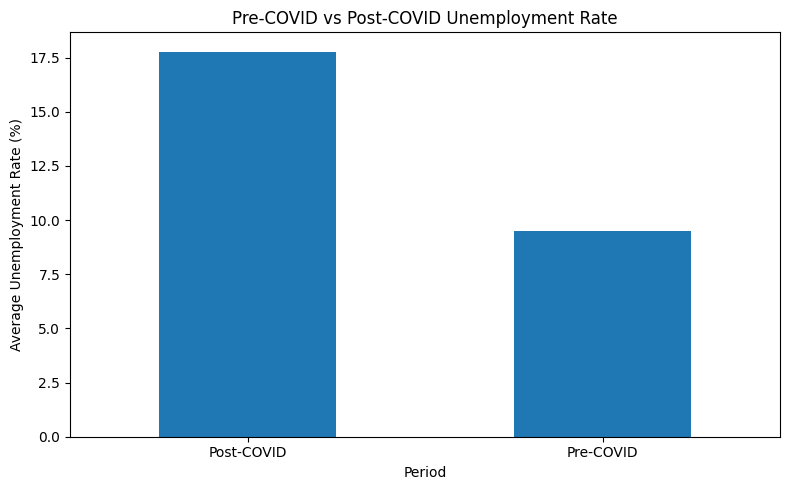

In [21]:
plt.figure(figsize=(8, 5))

covid_comparison.plot(kind='bar')

plt.title('Pre-COVID vs Post-COVID Unemployment Rate')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Key Observations

- Unemployment rates vary across different regions in India.
- The month-wise trend shows noticeable changes in unemployment over time.
- The selected three states show different unemployment rate patterns.
- The top 10 regions have comparatively higher average unemployment rates.
- The correlation heatmap shows relationships among the numerical variables.
- Unemployment rates changed significantly during the COVID-19 period compared with the pre-COVID period.

# Conclusion

The Unemployment Analysis with Python provided useful insights into unemployment trends across different regions and time periods in India. Through data cleaning, exploratory data analysis, visualization, and correlation analysis, regional and temporal patterns were identified. The comparison between pre-COVID and post-COVID periods also highlighted the impact of the COVID-19 pandemic on unemployment rates. Overall, this analysis demonstrates how Python, Pandas, Matplotlib, and Seaborn can be used effectively to understand and visualize unemployment data.